In [165]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pyreadstat import read_sav
from pyreadstat import metadata_container

np.random.seed(42)

In [166]:
df: pd.DataFrame; meta: metadata_container
df, meta = read_sav('data.sav')
df = df.drop('k4_new', axis=1)
df.shape

(2695, 22)

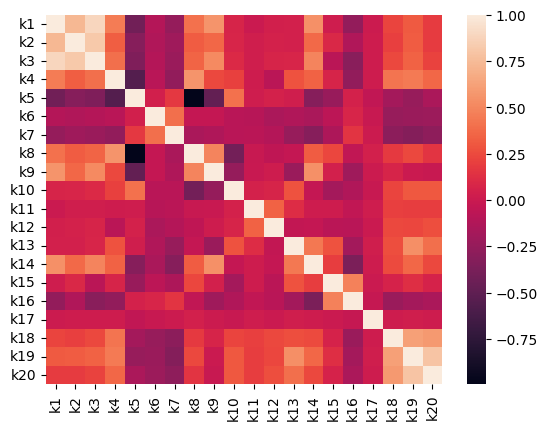

In [167]:
sns.heatmap(df[df.columns[1:-1]].corr())
plt.show()

df = df.drop('k8', axis=1)
NUM_COLS = df.columns[1:-1]

Нахождение выбросов (Isolation forest)

In [168]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest

df_train: pd.DataFrame; df_test: pd.DataFrame
df_train, df_test = train_test_split(df, train_size=0.7, random_state=42)
print(df_train.shape, df_test.shape)

clf = IsolationForest(
    n_estimators=200,           # Больше деревьев = стабильнее
    max_samples='auto',         # Можно попробовать 256, 512, 1024
    contamination='auto',       # или 0.05, или подобрать вручную
    max_features=0.8,           # Используем не все признаки сразу (боремся с шумом)
    bootstrap=False,
    random_state=42
)

clf.fit(df_train[NUM_COLS])
outliers_train: np.ndarray = clf.predict(df_train[NUM_COLS])

print(f"Number of outliers in train df: {np.abs( outliers_train[outliers_train == -1].sum() )}")

(1886, 21) (809, 21)
Number of outliers in train df: 88


Винсоризация:

In [169]:
percentiles = {}
for col in NUM_COLS:
    p_low = np.percentile(df_train[col], 5)
    p_high = np.percentile(df_train[col], 95)
    percentiles[col] = (p_low, p_high)

df_train_clean: pd.DataFrame = df_train.copy()
outliers_mask = (outliers_train == -1)
for col in NUM_COLS:
    low, high = percentiles[col]
    col_data = df_train_clean[col][outliers_mask]
    col_data[col_data < low] = low
    col_data[col_data > high] = high
    df_train_clean.loc[outliers_mask, col] = col_data

df_test_clean: pd.DataFrame = df_test.copy()
for col in NUM_COLS:
    low, high = percentiles[col]
    df_test_clean.loc[df_test_clean[col] < low, col] = low
    df_test_clean.loc[df_test_clean[col] > high, col] = high

Стандартизация:

In [170]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaler.fit(df_train_clean)

df_train_array: np.ndarray = scaler.transform(df_train_clean)
df_train_stand: pd.DataFrame = pd.DataFrame(df_train_array,
                                             columns=df_train_clean.columns,
                                               index=df_train_clean.index)


Метод главных компонент:

In [175]:
from sklearn.decomposition import PCA

n_pca_components: int = 14

pca = PCA(n_components=n_pca_components)
pca.fit(df_train_stand)
print(pca.explained_variance_ratio_)
print(np.cumsum(pca.explained_variance_ratio_))
pca_train_array: np.ndarray = pca.transform(df_train_stand)

pca_columns: list[str] = ['pca_' + str(i + 1) for i in range(n_pca_components)]
df_train_pca: pd.DataFrame = pd.DataFrame(pca_train_array, columns=pca_columns, index=df_train_stand.index)
print(df_train_pca.shape)
df_train_pca.head()

[0.24846892 0.12707393 0.09246084 0.07822157 0.05679927 0.0553527
 0.05074674 0.04604204 0.03859939 0.03426611 0.03238722 0.02803769
 0.02537887 0.02220721]
[0.24846892 0.37554285 0.46800369 0.54622526 0.60302453 0.65837722
 0.70912396 0.755166   0.79376539 0.8280315  0.86041872 0.8884564
 0.91383527 0.93604249]
(1886, 14)


,pca_1,pca_2,pca_3,pca_4,pca_5,pca_6,pca_7,pca_8,pca_9,pca_10,pca_11,pca_12,pca_13,pca_14
1511,-1.664880,-1.611050,1.103228,-1.601591,2.928585,0.300357,0.320349,0.352917,0.763480,0.932530,-1.051446,1.546773,1.867626,0.450976
1767,-0.924103,0.124808,2.530344,0.566273,2.472141,1.451046,0.612624,0.161734,1.058578,0.358435,-1.829865,0.755628,0.452202,-0.555309
1644,0.958705,-0.679924,0.110174,-1.052194,-2.035449,0.222865,-0.903969,-0.018661,-1.521514,-0.040175,-0.318590,0.770095,1.842463,-0.330071
2256,-0.774861,0.425964,-1.151594,0.115980,-0.887858,0.664014,-0.534251,0.275633,0.134103,0.311820,-0.188394,-0.175512,0.012807,-0.648150
275,0.218810,1.598174,1.844525,0.445337,0.970641,-1.054543,0.351159,-0.389709,-0.646032,0.564630,0.838768,-0.275140,0.224011,0.563736
